# Text-to-3D

> Everything to know about turning a text prompt into a 3D asset: representations, the SDS-vs-feed-forward split, the mid-2026 model landscape, why evaluation is still weak, and runnable code (Shap-E in `diffusers`) to generate, render and export a mesh on a 12 GB card.

- skip_showdoc: true
- skip_exec: true

## 1. What is Text-to-3D?

Text-to-3D maps a natural-language prompt ("a wooden rocking chair") to a **3D asset**. Unlike text-to-image, there is no single canonical output format: the task is only defined once you say *which representation* you want back. That choice is the whole design decision, and everything else in the pipeline follows from it.

**Input.** A text prompt, encoded by a frozen text encoder (CLIP text tower in Shap-E and Point-E; T5 / CLIP in the diffusion priors; a VLM caption embedding in the newest systems).

**Output.** One of these, and they are not interchangeable:

| Representation | What it is | Pros | Cons | Who wants it |
|----------------|-----------|------|------|--------------|
| **Point cloud** | Unordered (x, y, z) + colour samples | Trivial to generate, permutation-invariant, cheap | No surface, no topology, cannot be textured or rendered directly | Intermediate only (Point-E) |
| **Voxel grid** | Occupancy/colour on a 3D lattice | Convolution-friendly, simple | Memory is O(n^3); 512^3 is already huge; blocky | Coarse stage of generators (TRELLIS sparse voxels) |
| **Mesh** (triangles + UVs + textures) | Vertices, faces, UV map, PBR material maps | **The only thing game engines and DCC tools actually ingest**; riggable, animatable, editable | Hard to generate directly (irregular, variable topology) | Games, film, AR/VR, product viz, 3D print |
| **Implicit field** (SDF / occupancy) | A network f(x, y, z) -> distance or inside/outside | Arbitrary resolution, watertight by construction, smooth | Must be marching-cubed to a mesh; extraction is lossy and produces dense, ugly topology | Learned shape latents (DeepSDF, TRELLIS, Hunyuan3D-DiT) |
| **NeRF** (radiance field) | A network mapping (x, y, z, view dir) -> colour + density | Beautiful novel-view synthesis, view-dependent effects | Slow to fit and to render, **not a mesh**, no material separation | Optimisation-based methods (DreamFusion) |
| **3D Gaussian Splatting** (2023) | Millions of explicit anisotropic 3D Gaussians | Real-time rasterised rendering, explicit, fast to fit; now dominant for **capture** | Not a mesh either; enormous file sizes; meshing a splat is its own research problem | Capture / scene reconstruction, and one of TRELLIS's output heads |
| **Structured / native 3D latent** | A compact learned latent grid that *decodes* to any of the above | Lets a single diffusion model be trained on 3D data and emit mesh + splat + radiance field | Needs a big 3D corpus to train the VAE | Modern feed-forward generators (TRELLIS, Hunyuan3D) |

**The practical consequence:** a text-to-3D system that produces a gorgeous NeRF has produced nothing a game studio can use. Judge output quality **on the representation the downstream user needs** - for most commercial use that means a clean, watertight, low-poly, **UV-unwrapped mesh with PBR maps**. A pipeline that does not end there is a research demo, not a production tool.

**Neighbouring tasks:**

| Task | What it does | See |
|------|--------------|-----|
| Text-to-image | The 2-D prior that almost every 3D method leans on | `04_Text_to_Image` |
| Image-to-3D | Single/multi-image -> 3D asset; the reconstruction half of the story | `15_Image_to_3D` |
| Depth estimation | Per-pixel depth: 2.5-D, not a full 3D asset | `00_Depth_Estimation` |
| Novel-view synthesis | Render unseen viewpoints of a *captured* scene (NeRF, 3DGS) | (capture, not generation) |
| Text-to-video | The other "add a dimension to diffusion" task | `10_Text_to_Video` |

---

## 2. Real-World Use Cases

3D generation is the youngest of the generative modalities and the one where the gap between demo and deployment is widest - because the deliverable is an *engineering artifact*, not a picture.

| Use case | Domain | Consumes / produces | Dominant constraint |
|----------|--------|---------------------|---------------------|
| Game asset prototyping (props, greybox kit-bashing) | Games (Unity/Unreal studios; Meshy, Tripo, Rodin as tools) | Prompt -> textured GLB dropped into the engine | **Mesh hygiene**: manifold, watertight, sane poly count, UVs; the artist must be able to fix it |
| Product visualisation and e-commerce 3D | Retail (Amazon AR View, Shopify 3D) | Prompt or product photo -> GLB/USDZ for web AR | Metric accuracy and brand fidelity; a hallucinated logo is worse than no model |
| AR/VR and metaverse content | XR (Apple Vision Pro, Meta Horizon) | Prompt -> low-poly asset, runtime budget in the low thousands of triangles | On-device render budget; draw calls; file size |
| Film/VFX previs and set dressing | Media | Prompt -> rough geometry for layout, later replaced by hand-made assets | Speed and iteration count, not final quality; must round-trip through Blender/Maya |
| Simulation and robotics assets | Robotics, autonomous driving (Isaac Sim, Objaverse-derived sim scenes) | Prompt -> mesh + collision + mass properties | Physical plausibility, collision geometry, scale in metres |
| 3D printing | Manufacturing, hobbyist | Prompt -> **watertight, manifold** solid | Printability: no self-intersections, no non-manifold edges, no zero-thickness shells |
| Architecture / interior design | AECO | Prompt -> furniture and fixture library | Real-world dimensions; catalogue consistency |
| Avatars | Social, gaming | Prompt or selfie -> **rigged** humanoid | Riggability and topology loops around joints; a generated blob cannot be animated |

**What the leaderboard number hides.** Every public text-to-3D ranking scores *renders*, so it rewards a model that looks good from four camera angles and says nothing about whether the mesh is usable. In production the failure modes that kill a project are structural: **non-manifold edges and holes** (the model will not slice for printing and will not shade correctly), **100k-triangle blobs with no UV seams** (unusable in a real-time engine without a retopology and bake pass that costs more artist time than modelling it by hand), **baked lighting** in the albedo map instead of a proper PBR material set (the asset looks wrong under any other light), and **scale ambiguity** (the model has no idea a chair is 0.9 m tall). Then there is the licensing question nobody wants to answer: the models are trained on Objaverse, which is a scrape, and the provenance of a generated asset is murky. The honest summary of mid-2026: 3D generation is production-ready for **rapid concepting and background props**, and still not for hero assets.

---

## 3. How Modern Text-to-3D Works

The field split into two paradigms in 2022, they raced for about two years, and the second one won decisively.

### Paradigm 1: optimisation-based, via Score Distillation Sampling (2022-2023)

**The problem it solves:** in 2022 there was no 3D training data at anything like the scale of LAION. So **DreamFusion** (Poole et al., Google, Sept 2022) asked: can we generate 3D *without any 3D data at all*, using only a frozen 2-D text-to-image diffusion model as a critic?

**Score Distillation Sampling (SDS)** is the answer, and it is a genuinely lovely idea. Randomly initialise a NeRF with parameters `theta`. Render it from a random camera to get an image `x = g(theta)`. Add noise to that render. Ask the frozen 2-D diffusion model (Imagen, later Stable Diffusion) to predict the noise, *conditioned on the text prompt*. The difference between the noise you added and the noise the model predicts is a signal that says **"here is how this render should change to look more like the prompt to a 2-D prior"**. Backpropagate that residual through the differentiable renderer into `theta`:

$$\nabla_{\theta}\,\mathcal{L}_{SDS} = \mathbb{E}_{t,\epsilon}\Big[ w(t)\,\big(\hat{\epsilon}_{\phi}(x_t; y, t) - \epsilon\big)\,\frac{\partial x}{\partial \theta} \Big]$$

Note what is *missing*: no U-Net Jacobian term (it is dropped, which is what makes SDS tractable), no 3D data, no 3D model. The 2-D prior is doing all the work; the NeRF is just a 3D-consistent canvas that averages the prior's opinions over many viewpoints.

**Its pathologies are legendary:**

- **The Janus / multi-face problem.** The 2-D prior has no idea what "the back of a corgi" looks like - it was trained on internet photos, which are overwhelmingly front views. So every viewpoint gets optimised toward a *front* view, and you get a dog with faces on both ends. This is the single most cited failure of SDS and it is inherent: a 3D-unaware prior cannot supervise 3D consistency.
- **Oversaturation and cartoonish colour**, caused by the enormous classifier-free guidance scale (~100) SDS needs to converge at all.
- **Blurry, over-smoothed geometry** - SDS is mode-seeking, so it collapses to a blurry average of the plausible shapes.
- **30-90 minutes per asset** on a good GPU. Per asset. This alone made it commercially dead.

**The follow-ups**, each fixing one pathology: **Magic3D** (NVIDIA, Nov 2022) - coarse NeRF then a fine DMTet mesh stage, ~2x faster and 8x higher resolution. **Fantasia3D** (2023) - disentangle geometry (DMTet) from appearance (a real BRDF), so you get usable PBR materials out. **ProlificDreamer** (2023) - replaces SDS with **Variational Score Distillation (VSD)**, treating the 3D scene as a *distribution* rather than a single point estimate, which fixes the oversaturation and blur (at the cost of even more compute). **MVDream** (ByteDance, 2023) - the key idea: fine-tune the 2-D prior on multi-view renders of Objaverse so it becomes **multi-view aware**, then distil *that*. Janus largely disappears. And note what MVDream implicitly conceded: the fix for a 2-D prior's lack of 3D knowledge is to train it on 3D data. Which raises the obvious question - why not just train a 3D generator directly?

### Paradigm 2: feed-forward native 3D generation (2023-2026) - the winner

**Objaverse** (800K 3D objects, 2022) and **Objaverse-XL** (10.2M, 2023) made the obvious question answerable. Once you have millions of 3D assets, you can train a generator on 3D directly and produce an asset in **seconds** rather than an hour.

1. **Point-E** (OpenAI, Dec 2022) and **Shap-E** (OpenAI, May 2023). The first *fast* ones: 1-2 minutes, then seconds. Point-E diffuses a point cloud; Shap-E diffuses the *parameters of an implicit function* (a NeRF/SDF), so it can decode to a mesh. Quality is crude - blobby, low-frequency, wrong-looking - but they proved the direction, and Shap-E is the one runnable text-to-3D model in `diffusers` today (sections 8-10 below).
2. **Multi-view diffusion, then reconstruct.** **Zero-1-to-3** (2023) fine-tunes a 2-D diffusion model to synthesise a *specified novel viewpoint* of an object. **One-2-3-45** (2023) chains that into a 45-second image-to-mesh pipeline. **Instant3D** (2023) generates a 4-view grid in one diffusion pass, then reconstructs. This is the template most systems still follow.
3. **Large Reconstruction Models (LRM, 2023)** and successors (**InstantMesh**, **TripoSR**, **Stable Fast 3D**): a big transformer that maps image tokens straight to a triplane NeRF / mesh in **under a second**, no per-asset optimisation at all. TripoSR runs in ~0.5 s on an A100.
4. **Native 3D latent diffusion (2024-2026)** - the current state of the art. **TRELLIS** (Microsoft, Dec 2024) introduced **structured latents (SLat)**: a sparse-voxel-anchored latent that a single flow model generates and that separate decoders turn into a **mesh, a 3D Gaussian splat, or a radiance field** - the representation choice becomes a decoding choice. **TRELLIS.2** (Dec 2025, 4B params, MIT) replaces SLat with a field-free "O-Voxel" structure, hits 1536-resolution assets with PBR materials in under 20 s on a 24 GB card, and is currently the open quality leader. **Hunyuan3D 2.x/3.0** (Tencent, 2025) splits the problem into **Hunyuan3D-DiT** (flow-matching shape generation) and **Hunyuan3D-Paint** (PBR texture synthesis), fully open-sourced including training code, at 1536^3 geometric resolution - the strongest open alternative and the one most used in production. **TripoSG** (VAST-AI) is a rectified-flow shape model in the same family. Closed products (**Meshy**, **Tripo**, **Rodin**, **Luma**) wrap the same ideas with a retopology + UV + PBR-bake back end, which is most of what you are actually paying for.

### The most useful practical fact in this notebook

**Almost no serious "text-to-3D" system is actually text-to-3D.** TRELLIS.2, Hunyuan3D, TripoSG, TripoSR, Stable Fast 3D and every commercial product are **image-conditioned**. The text path is a two-stage cascade: **text -> image (a good T2I model) -> 3D (an image-to-3D model)**. That is not a hack; it is the right architecture. The T2I model has seen billions of images and knows what a "Art Deco brass table lamp" looks like; the 3D model has seen ~10M objects and mostly needs to know the *shape*. Conditioning on a single clean reference image concentrates all the semantic difficulty in the modality that has the data.

So: the text side of this notebook is a thin front-end, and **`15_Image_to_3D` is the load-bearing notebook** - it owns the reconstruction detail (multi-view generation, triplane/LRM decoding, mesh extraction, texture baking). Here we own the *conditioning* story and the SDS-vs-feed-forward argument.

**Cheat sheet:**

| Approach | Time per asset | 3D data needed | Output | Janus | Status mid-2026 |
|----------|----------------|----------------|--------|-------|-----------------|
| SDS on a 2-D prior (DreamFusion) | 30-90 min | none | NeRF | severe | historical; the idea that started it |
| SDS + multi-view prior (MVDream) | 15-40 min | Objaverse (for the prior) | NeRF/mesh | mostly fixed | niche: high quality, no time limit |
| VSD (ProlificDreamer) | hours | none | NeRF/mesh | present | research; best SDS-family fidelity |
| Feed-forward implicit (Shap-E) | ~10 s | millions of assets | mesh/NeRF | n/a | runnable, obsolete quality |
| Multi-view diffusion + LRM | 1-45 s | Objaverse(-XL) | mesh | mild | the standard template |
| Native 3D latent (TRELLIS.2, Hunyuan3D) | 10-30 s | Objaverse-XL + private | mesh + PBR + 3DGS | n/a | **state of the art** |
| Text -> image -> 3D cascade | T2I + 3D | - | whatever the 3D stage emits | n/a | **what you actually deploy** |

---

## 4. Evaluation Metrics

**Be honest up front: 3D generation evaluation is weak, contested, and does not measure what users care about.** There is no FID-equivalent that everyone trusts.

**1. CLIP score / CLIP R-Precision (the standard text-to-3D metric).** Render the asset from `K` viewpoints, embed the renders with CLIP, embed the prompt, and measure similarity:

$$\text{CLIPScore} = \frac{1}{K}\sum_{k=1}^{K} \cos\!\big(E_I(r_k),\, E_T(y)\big)$$

**R-Precision** is the retrieval version: given the asset's renders and a pool of `N` captions (the true prompt plus `N-1` distractors), how often is the true prompt ranked first?

$$\text{R-Precision} = \frac{1}{M}\sum_{i=1}^{M} \mathbb{1}\Big[\arg\max_{j} \cos\big(\bar{E}_I(a_i), E_T(y_j)\big) = i\Big]$$

**Its blind spot is fatal and worth stating plainly:** it is computed on 2-D renders, so it measures "does this look like the prompt from a camera", *not* "is this a valid 3D object". A Janus corgi with two faces scores *higher* than a correct one, because every view looks like a front view. Broken topology, inverted normals, floating disconnected shards, and a hollow shell all cost approximately nothing.

**2. FID / KID on renders.** Distribution-level realism of the renders. Inherits the same blind spot, plus FID's usual sensitivity to sample count.

**3. Geometry metrics (only when a ground-truth mesh exists).** These apply to *reconstruction* (see `15_Image_to_3D`), not to open-ended generation from a prompt - there is no ground truth for "a wooden rocking chair".

- **Chamfer distance** between point sets `X` and `Y` sampled from the two surfaces (lower is better; sensitive to outliers, and it is scale-dependent so both meshes must be normalised into the same unit box):

$$d_{CD}(X, Y) = \frac{1}{|X|}\sum_{x \in X} \min_{y \in Y} \lVert x - y \rVert_2^2 \;+\; \frac{1}{|Y|}\sum_{y \in Y} \min_{x \in X} \lVert x - y \rVert_2^2$$

- **F-score at threshold `tau`** - the harmonic mean of precision (fraction of predicted points within `tau` of the GT surface) and recall (fraction of GT points within `tau` of the prediction). Far more interpretable than Chamfer and much less outlier-sensitive; `tau` is usually 1% of the bounding-box diagonal.
- **Earth Mover's distance** (optimal transport between the point sets - better distributed but O(n^3)-ish to compute), **normal consistency** (are the surface orientations right), and **volumetric IoU** of the occupancy grids.

**4. The metrics that actually matter to a user, and that no benchmark reports.** Is the mesh **watertight** and **2-manifold**? What is the **triangle count** (2k or 200k)? Is it **UV-unwrapped** with non-overlapping islands? Are there real **PBR maps** (albedo / normal / roughness / metallic) or is lighting baked into the albedo? Is the topology **riggable**? Is the **scale** right? A model can win every leaderboard and fail all seven.

**5. Holistic attempts.** **T3Bench** (2023) scores quality and alignment with multi-view captioning + an LLM judge. **GPTEval3D** (2024) uses GPT-4V for pairwise comparison against a set of criteria and produces an Elo. **3DGen-Bench / 3DGen-Arena** and **3D Arena** run human pairwise voting - which, as in every generative modality, remains the only evaluation anyone really believes.

**6. Speed.** Seconds per asset, and VRAM. A 60-minute SDS run and a 10-second feed-forward run are not competing on the same axis.

Chamfer and F-score are the only ones we can compute honestly in a cell, so start there:

In [ ]:
import numpy as np

rng = np.random.default_rng(0)

def sample_sphere(n, radius=1.0, jitter=0.0, center=(0.0, 0.0, 0.0)):
    "Sample n points on a sphere surface (a stand-in for a mesh surface sampling)."
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    v *= radius + jitter * rng.normal(size=(n, 1))
    return v + np.asarray(center)

def chamfer(x, y):
    "Symmetric squared-L2 Chamfer distance between two point clouds (N,3) and (M,3)."
    d2 = ((x[:, None, :] - y[None, :, :]) ** 2).sum(-1)   # (N, M) pairwise squared distances
    return float(d2.min(1).mean() + d2.min(0).mean())

def f_score(pred, gt, tau):
    "F-score at distance threshold tau: harmonic mean of precision and recall."
    d = np.sqrt(((pred[:, None, :] - gt[None, :, :]) ** 2).sum(-1))
    precision = float((d.min(1) < tau).mean())   # predicted points near the GT surface
    recall = float((d.min(0) < tau).mean())      # GT points covered by the prediction
    if precision + recall == 0:
        return 0.0, precision, recall
    return 2 * precision * recall / (precision + recall), precision, recall

gt = sample_sphere(600)                                  # "ground truth" surface
good = sample_sphere(600, jitter=0.02)                   # a faithful reconstruction
bad = sample_sphere(600, radius=1.15, jitter=0.05)       # a bloated one
shifted = sample_sphere(600, center=(0.25, 0, 0))        # right shape, wrong pose

TAU = 0.05  # ~1% of the bounding-box diagonal for a unit-ish object
for name, pred in [("faithful", good), ("bloated", bad), ("misaligned", shifted)]:
    f, p, r = f_score(pred, gt, TAU)
    print(f"{name:12s} chamfer {chamfer(pred, gt):.5f}   F@{TAU} {f:.3f} (P {p:.3f} / R {r:.3f})")

# Note how Chamfer punishes the misaligned copy hard while its *shape* is perfect -
# both metrics assume the two meshes are already normalised and registered into the
# same coordinate frame. Get that wrong and the numbers are meaningless.

faithful     chamfer 0.01471   F@0.05 0.282 (P 0.275 / R 0.288)
bloated      chamfer 0.05824   F@0.05 0.003 (P 0.003 / R 0.003)
misaligned   chamfer 0.05824   F@0.05 0.042 (P 0.040 / R 0.043)


In [ ]:
# CLIP R-Precision over rendered views - the standard text-to-3D metric. We reuse
# these two helpers in the benchmark (section 11) to score Shap-E's renders.
from transformers import CLIPModel, CLIPProcessor

CLIP_ID = "openai/clip-vit-base-patch32"

def load_clip(model_id=CLIP_ID):
    "Load CLIP once; the caller frees it. Keeps us from holding two models live."
    proc = CLIPProcessor.from_pretrained(model_id, cache_dir=HF_CACHE)
    model = CLIPModel.from_pretrained(model_id, cache_dir=HF_CACHE).to(device).eval()
    return model, proc

def clip_view_scores(views, captions, clip):
    "Mean cosine similarity (x100) between the K rendered views and each caption -> (n_captions,)."
    model, proc = clip
    with torch.inference_mode():
        inputs = proc(text=captions, images=list(views), return_tensors="pt", padding=True).to(device)
        # logits_per_image is cosine similarity * learned temperature: (K views, C captions)
        sims = model(**inputs).logits_per_image.float().cpu().numpy()
    return sims.mean(axis=0)   # average over viewpoints -> one score per caption

def r_precision(views, true_prompt, distractors, clip):
    "1 if the true prompt outranks every distractor on the asset's renders, else 0."
    scores = clip_view_scores(views, [true_prompt] + list(distractors), clip)
    return float(np.argmax(scores) == 0), float(scores[0])

# Reminder: this only ever looks at renders. It cannot see a hole in the mesh.

## 5. Datasets

Text-to-3D was unlocked by a dataset, not by an architecture. Before Objaverse there was nothing to train a native 3D generator on; ShapeNet's 51K CAD models across 55 categories are not enough to learn open-vocabulary generation.

| Dataset | Contents | Size | Scope | License | Typical use |
|---------|----------|------|-------|---------|-------------|
| [Objaverse](https://huggingface.co/datasets/allenai/objaverse) | Sketchfab 3D objects with metadata | 800K | Open-vocabulary objects, wildly variable quality | ODC-By 1.0 (per-object CC licenses) | **The** training set for feed-forward 3D |
| [Objaverse-XL](https://huggingface.co/datasets/allenai/objaverse-xl) | Objects from GitHub, Thingiverse, Sketchfab, Polycam, SMK | 10.2M | The largest open 3D corpus | ODC-By 1.0 | Pretraining TRELLIS / LRM-class models |
| [Cap3D](https://huggingface.co/datasets/tiange/Cap3D) | **Text captions for Objaverse objects** (BLIP2 + GPT-4 over multi-view renders, human-checked) | ~1M captions | Object descriptions | ODC-By 1.0 | **What makes text conditioning trainable at all** |
| [ShapeNet](https://shapenet.org/) | Clean, category-labelled CAD models | 51K (Core), 3M (full) | 55 categories | Research-only, **registration-gated** | The classic benchmark; still used for reconstruction metrics |
| [ABO](https://amazon-berkeley-objects.s3.amazonaws.com/index.html) (Amazon Berkeley Objects) | Artist-made product models with real PBR materials + catalogue metadata | ~8K 3D / 147K products | Household products | CC BY-NC 4.0 | Material/texture realism, product viz |
| [Google Scanned Objects](https://huggingface.co/datasets/google/scanned-objects) | Photogrammetry scans of real household items | ~1K | Real objects, metric scale | CC BY 4.0 | Reconstruction eval, robotics sim |
| [OmniObject3D](https://omniobject3d.github.io/) | Real scanned objects with multi-view video + point clouds | 6K objects / 190 categories | Real-world, category-rich | CC BY-NC 4.0 | Eval of generation + reconstruction |

**Why Cap3D matters.** Objaverse's own metadata is Sketchfab junk ("model_23_final_v2"). You cannot condition on that. Cap3D renders each object from several views, captions the renders with a VLM, consolidates the captions with an LLM, and produces a usable text description - so the (text, 3D) pairs that a text-conditioned 3D model needs are *synthetic captions over a scraped 3D corpus*. Every text-to-3D model you use is, at one remove, trained on a 2-D captioner's opinion of a 3D object.

**What this notebook uses.** Nothing gated and nothing large: we generate from a handful of prompts and score the renders with CLIP. There is no ground-truth mesh for "a shark", which is exactly the point made in section 4 - open-ended generation has no reference to compare against.

---

## 6. The Model Landscape (mid-2026)

| Model | Params | License | Scope | Architecture | Best for |
|-------|--------|---------|-------|--------------|----------|
| [TRELLIS.2-4B](https://huggingface.co/microsoft/TRELLIS.2-4B) (Microsoft, Dec 2025) | 4B | MIT | image-to-3D (text via a T2I front-end) | Flow-matching DiT over "O-Voxel" structured latents; decodes to mesh / 3DGS / radiance field, PBR + transparency | **Open quality leader.** 1536-res assets in <20 s on a 24 GB card |
| [Hunyuan3D 2.1 / 3.0](https://huggingface.co/tencent/Hunyuan3D-2.1) (Tencent, 2025) | ~3B shape + paint | Tencent community license (open weights + training code) | image/text-to-3D | Hunyuan3D-DiT (flow-matching shape) + Hunyuan3D-Paint (PBR texture); 3.0 pushes 1536^3 geometry | Best **production** open option: real PBR maps, game-ready output |
| [TripoSG](https://huggingface.co/VAST-AI/TripoSG) (VAST-AI, 2025) | 1.5B | MIT | image-to-3D | Rectified-flow transformer over a shape VAE | High-fidelity shape, permissive license |
| [Stable Fast 3D](https://huggingface.co/stabilityai/stable-fast-3d) (Stability, 2024) | ~1B | Stability community (non-commercial below a revenue cap) | image-to-3D | LRM successor with **UV unwrapping + material estimation** built in | The one that actually emits a game-ready UV'd mesh, in ~0.5 s |
| [TripoSR](https://huggingface.co/stabilityai/TripoSR) (Stability + Tripo, 2024) | ~0.5B | MIT | image-to-3D | Transformer -> triplane NeRF, feed-forward | Fastest sane baseline; ~0.5 s/asset, runs on 6-8 GB |
| [Shap-E](https://huggingface.co/openai/shap-e) (OpenAI, 2023) | ~300M prior + transmitter | MIT | **text**-to-3D (and img2img) | Latent diffusion over *implicit-function weights*; decodes to NeRF or mesh | **The only diffusers-native text-to-3D pipeline.** Runnable here; quality is poor |
| Point-E (OpenAI, 2022) | ~1B (cascade) | MIT | text-to-3D | Diffusion over coloured point clouds + upsampler | Historical; point cloud only, not in `diffusers` |
| MVDream / ProlificDreamer / DreamFusion | n/a (optimisation) | varied | text-to-3D | SDS/VSD against a 2-D (or multi-view) prior | Research; minutes-to-hours per asset |
| Meshy 5 / Tripo 3.0 / Rodin / Luma | closed | commercial API | text- and image-to-3D | Feed-forward + a retopology/UV/bake back end | What studios actually buy: clean quad topology, UVs, PBR, rigging |

**Leaderboards.** [3DGen-Arena](https://huggingface.co/spaces/3DTopia/3DGen-Leaderboard) (human pairwise votes, separate text-to-3D and image-to-3D tracks) and [3D Arena](https://3darena.art/) (image-to-3D, ~123K votes) are the credible public rankings. Treat single-paper CLIP-score tables with suspicion for the reasons in section 4.

**Who wins what.** Quality: TRELLIS.2, then Hunyuan3D 3.0 (Hunyuan wins on *texture/PBR*, which is what a game pipeline needs). Speed: TripoSR / Stable Fast 3D, sub-second. Production-readiness: the closed products, because they own the retopology + UV + bake stage that the open models skip. Text-native and runnable in `diffusers`: only Shap-E, and it is three years behind.

**What fits a 12 GB RTX 3060.** Shap-E comfortably (it is small). TripoSR and Stable Fast 3D would fit but are **not diffusers-native** - they need the vendor `tsr` / `sf3d` repos, so they stay in this table. TRELLIS.2 (4B, needs a 24 GB card and the `trellis2` package) and Hunyuan3D (vendor `hy3dgen`) are **out of reach here on both counts**: too big and vendor-only. Tying this back to section 2: if you need a game-ready asset today, you run **text -> image (SD/FLUX) -> Hunyuan3D or TRELLIS.2** on a 24-48 GB card, or you buy an API. What you can honestly *demo* on this box is the shape of the pipeline, with Shap-E standing in for the 3D stage.

---

## 7. Setup

Package roles:

- `diffusers` + `torch` - `ShapEPipeline` / `ShapEImg2ImgPipeline` (the only text-to-3D pipelines in the HF ecosystem), plus `export_to_gif` / `export_to_ply`
- `transformers` - CLIP for the R-Precision metric, and the text encoder inside Shap-E
- `accelerate` - device placement
- `trimesh` - optional, to convert the exported `.ply` into a `.glb` a game engine can open
- `pyecharts` - all charts (including the 3D vertex scatter)
- `pandas`, `numpy` - benchmark table and the toy metrics

No vendor 3D packages (`trellis2`, `hy3dgen`, `tsr`, `sf3d`) are imported anywhere below - they are named in prose only.

All downloads (HF cache, sample image, generated GIF/PLY) land in `DL_tasks/datasets/`, which is gitignored.

---

In [ ]:
# Everything runs through Hugging Face diffusers/transformers - no vendor 3D packages.
# %pip install -q torch diffusers transformers accelerate pyecharts pandas

# Optional: convert the exported .ply mesh to .glb for a game engine / Blender
# %pip install -q trimesh

In [ ]:
import ctypes
import ctypes.util
import gc
import time
import urllib.request
from pathlib import Path

import torch
from dotenv import find_dotenv, load_dotenv

# Knowledge/.env sets HF_TOKEN - authenticated HF Hub requests get higher rate limits
load_dotenv(find_dotenv(usecwd=True))

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device != "cpu" else torch.float32
if device != "cpu":
    print(torch.cuda.get_device_name(0))
print("device:", device)

def vram(tag=""):
    "Report current GPU memory (allocated / reserved). No-op on CPU."
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM {tag:20s} {alloc:5.2f} GB allocated / {reserved:5.2f} GB reserved")

def free_memory():
    "Collect garbage, empty the CUDA cache, and return freed CPU RAM to the OS."
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    # glibc keeps freed CPU allocations in its arenas instead of returning them
    # to the OS, so RSS compounds across model sections (cpu-offloaded weights
    # live in system RAM). malloc_trim(0) hands the freed arenas back. See
    # dl-visualization-and-memory.instructions.md - not optional on a 12 GB box.
    try:
        ctypes.CDLL(ctypes.util.find_library("c") or "libc.so.6").malloc_trim(0)
    except Exception:
        pass

# All downloads go to DL_tasks/datasets/ (gitignored)
DATA_DIR = Path("../../datasets")
DATA_DIR.mkdir(exist_ok=True)
HF_CACHE = str(DATA_DIR / "hf_cache")

OUT_DIR = DATA_DIR / "text_to_3d"
OUT_DIR.mkdir(exist_ok=True)

NVIDIA GeForce RTX 3060
device: cuda:0


(256, 256)


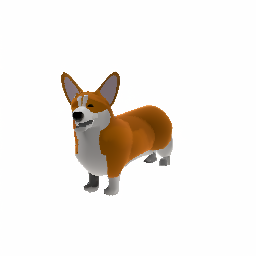

In [ ]:
from PIL import Image

# The four prompts we generate and benchmark on. Deliberately simple, compact,
# single-object prompts - Shap-E falls apart on anything compositional.
PROMPTS = [
    "a shark",
    "a red sports car",
    "a wooden chair",
    "a birthday cupcake",
]

# Reference image for the image-conditioned path (section 10). In production this
# image would come out of a text-to-image model (see 04_Text_to_Image); we cache a
# stable one so the notebook does not need a second large model to run.
REF_IMAGE = OUT_DIR / "corgi.png"
if not REF_IMAGE.exists():
    urllib.request.urlretrieve(
        "https://hf.co/datasets/diffusers/docs-images/resolve/main/shap-e/corgi.png",
        REF_IMAGE,
    )

ref_image = Image.open(REF_IMAGE).convert("RGB").resize((256, 256))
print(ref_image.size)
ref_image

## 8. Shap-E: text-to-3D (`openai/shap-e`)

The only text-to-3D pipeline that is native to `diffusers`, and therefore the only one this notebook can honestly run. Architecture recap: a ~300M-parameter latent diffusion prior generates the **weights of an implicit function** (an MLP that maps a 3D coordinate to density + colour), and a "transmitter" decoder renders that function as a NeRF or marching-cubes it into a mesh. Because the latent *is* a shape, generation takes seconds, not the 30-90 minutes an SDS method needs.

**Set expectations.** By 2026 standards Shap-E's output is bad: blobby, low-frequency, muddy colours, no fine detail, and it fails on anything compositional ("a cat wearing a hat riding a skateboard" produces mush). It is here because it is fast, small, MIT-licensed, and diffusers-native - a working end-to-end demonstration of the feed-forward paradigm, not a model you would ship. Everything above it in the section-6 table needs a vendor repo, a bigger card, or both.

Knobs: `guidance_scale` (15.0 is the documented default for text; higher = more prompt-faithful, more distorted), `num_inference_steps` (64 is the usual setting), `frame_size` (render resolution of the turntable frames - **this only affects rendering cost, not shape quality**).

---

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

The config attributes {'renderer': ['shap_e', 'ShapERenderer']} were passed to ShapEPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'renderer': ['shap_e', 'ShapERenderer']} are not expected by ShapEPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/127 [00:00<?, ?it/s]

34.0s for 20 rendered views
VRAM shap-e loaded         1.35 GB allocated /  4.13 GB reserved


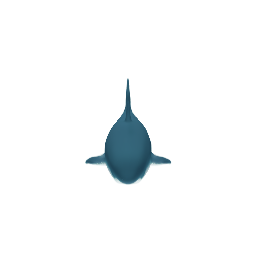

In [ ]:
from diffusers import ShapEPipeline
from diffusers.utils import export_to_gif
from IPython.display import Image as IPyImage, display

pipe = ShapEPipeline.from_pretrained(
    "openai/shap-e",
    torch_dtype=dtype,
    cache_dir=HF_CACHE,
).to(device)

prompt = "a shark"
t0 = time.perf_counter()
frames = pipe(
    prompt,
    guidance_scale=15.0,
    num_inference_steps=64,
    frame_size=256,      # turntable render resolution
).images[0]              # -> a list of PIL frames orbiting the object
print(f"{time.perf_counter() - t0:.1f}s for {len(frames)} rendered views")
vram("shap-e loaded")

gif_path = export_to_gif(frames, str(OUT_DIR / "shark.gif"))
display(IPyImage(filename=gif_path))

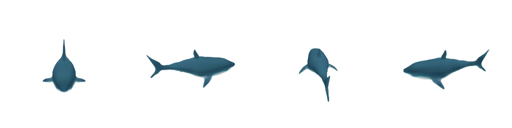

In [ ]:
# A static contact sheet of the turntable, so the rendered docs show something even
# where the animated GIF does not play. (PIL for image display; ECharts is for charts.)
def contact_sheet(views, cols=4, size=128):
    "Tile a list of PIL frames into a single strip/grid image."
    picks = views[:: max(1, len(views) // cols)][:cols]
    sheet = Image.new("RGB", (cols * size, size), "white")
    for i, im in enumerate(picks):
        sheet.paste(im.resize((size, size)), (i * size, 0))
    return sheet

contact_sheet(frames)

## 9. Shap-E: mesh export (the output that actually matters)

The GIF above is a NeRF turntable - pretty, and useless to a game engine. Pass `output_type="mesh"` and the transmitter runs marching cubes over the implicit field instead, giving a `MeshDecoderOutput` with `.verts`, `.faces` and per-vertex RGB in `.vertex_channels`. `export_to_ply` writes it to disk; `trimesh` converts it to a `.glb`.

This is where the honest critique of the whole pipeline lands. What comes out is a **dense triangle soup with per-vertex colours**: no UV map, no texture image, no PBR material set, no guaranteed manifoldness, and a poly count set by the marching-cubes resolution rather than by what the asset needs. Compare with the section-2 requirements - that is why Stable Fast 3D's built-in UV unwrapping, and Hunyuan3D-Paint's PBR maps, are the features that separate a research output from a shippable one.

We plot the vertices as a **pyecharts Scatter3D**, which is a legitimate use of ECharts: it is a scatter plot that happens to have three axes.

---

In [ ]:
from diffusers.utils import export_to_ply
from pyecharts import options as opts
from pyecharts.charts import Scatter3D

t0 = time.perf_counter()
mesh = pipe(
    prompt,
    guidance_scale=15.0,
    num_inference_steps=64,
    frame_size=256,
    output_type="mesh",
).images[0]
print(f"{time.perf_counter() - t0:.1f}s")

verts = mesh.verts.detach().cpu().numpy()
faces = mesh.faces.detach().cpu().numpy()
print(f"{len(verts)} vertices / {len(faces)} triangles - no UVs, no material maps, per-vertex colour only")

ply_path = export_to_ply(mesh, str(OUT_DIR / "shark.ply"))
print("wrote", ply_path)

# Convert to a glb a game engine or Blender can open (optional, needs trimesh):
# import trimesh, numpy as np
# m = trimesh.load(ply_path)
# m.apply_transform(trimesh.transformations.rotation_matrix(-np.pi / 2, [1, 0, 0]))  # Shap-E is bottom-up
# m.export(str(OUT_DIR / "shark.glb"), file_type="glb")

# Subsample for the browser - ECharts will not enjoy 30k points.
step = max(1, len(verts) // 4000)
points = [[round(float(x), 4), round(float(z), 4), round(float(y), 4)] for x, y, z in verts[::step]]

scatter = (
    Scatter3D(init_opts=opts.InitOpts(width="760px", height="560px"))
    .add(
        "vertices",
        points,
        grid3d_opts=opts.Grid3DOpts(width=100, height=100, depth=100),
    )
    .set_series_opts(itemstyle_opts=opts.ItemStyleOpts(opacity=0.7))
    .set_global_opts(
        title_opts=opts.TitleOpts(title=f"Shap-E mesh vertices: '{prompt}'", subtitle=f"{len(points)} of {len(verts)} vertices"),
        visualmap_opts=opts.VisualMapOpts(
            dimension=2, min_=float(min(p[2] for p in points)), max_=float(max(p[2] for p in points)),
            range_color=["#313695", "#4575b4", "#74add1", "#fee090", "#f46d43", "#a50026"],
        ),
    )
)
scatter.render_notebook()

  0%|          | 0/127 [00:00<?, ?it/s]

9.1s
8970 vertices / 17932 triangles - no UVs, no material maps, per-vertex colour only
wrote ../../datasets/text_to_3d/shark.ply


## 10. The pipeline you would actually deploy: text -> image -> 3D

Section 3's punchline, made concrete. Every strong 3D generator is **image-conditioned**, so real "text-to-3D" is a cascade:

1. **Text -> image.** Generate one clean reference view of the object with a good T2I model on a plain background (see `04_Text_to_Image`; SDXL / SD 3.5 / FLUX all work, and a prompt suffix like *"single object, centred, plain white background, product photo"* matters more than the model choice).
2. **Image -> 3D.** Feed that image to an image-to-3D model. In production: TRELLIS.2 or Hunyuan3D on a 24 GB+ card. Here: `openai/shap-e-img2img`, the same architecture with a CLIP *image* embedding replacing the text embedding.

Why this beats text-conditioning directly: the T2I model has seen billions of images and knows what the object should look like; the 3D model has seen ~10M objects and mostly needs to know the *shape*. The reference image also gives you a cheap human checkpoint - if the render is wrong, regenerate the image, which takes seconds, instead of debugging the 3D stage.

Note the guidance scale drops to ~3.0 for the image path (an image embedding is a far stronger condition than a text embedding, so it needs much less pushing). `15_Image_to_3D` owns the rest of this story - multi-view generation, LRM/triplane decoding, mesh extraction and texture baking.

---

VRAM after shap-e text     0.01 GB allocated /  0.02 GB reserved


model_index.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

The config attributes {'renderer': ['shap_e', 'ShapERenderer']} were passed to ShapEImg2ImgPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'renderer': ['shap_e', 'ShapERenderer']} are not expected by ShapEImg2ImgPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e-img2img/snapshots/0e0aba80f08d368aaf6af9cb93583707481cc29b/prior: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e-img2img/snapshots/0e0aba80f08d368aaf6af9cb93583707481cc29b/prior.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e-img2img/snapshots/0e0aba80f08d368aaf6af9cb93583707481cc29b/shap_e_renderer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e-img2img/snapshots/0e0aba80f08d368aaf6af9cb93583707481cc29b/shap_e_renderer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/127 [00:00<?, ?it/s]

37.7s


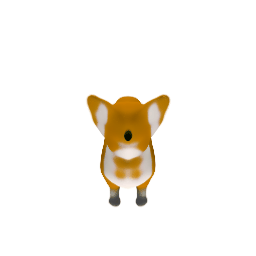

VRAM after shap-e img2img  0.01 GB allocated /  0.02 GB reserved


In [ ]:
# Free the text pipeline before loading the image one - never two models live at once.
del pipe, mesh
free_memory()
vram("after shap-e text")

from diffusers import ShapEImg2ImgPipeline

img_pipe = ShapEImg2ImgPipeline.from_pretrained(
    "openai/shap-e-img2img",
    torch_dtype=dtype,
    cache_dir=HF_CACHE,
).to(device)

# Stage 1 (text -> image) would go here. We use the cached reference instead of loading
# a second large model on a 12 GB card:
#
#   from diffusers import StableDiffusionXLPipeline
#   t2i = StableDiffusionXLPipeline.from_pretrained(
#       "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=dtype, cache_dir=HF_CACHE).to(device)
#   ref_image = t2i("a corgi, single object, centred, plain white background, product photo",
#                   num_inference_steps=30).images[0].resize((256, 256))
#   del t2i; free_memory()

t0 = time.perf_counter()
img_frames = img_pipe(
    ref_image,
    guidance_scale=3.0,   # much lower than text: the image embedding is a strong condition
    num_inference_steps=64,
    frame_size=256,
).images[0]
print(f"{time.perf_counter() - t0:.1f}s")

display(IPyImage(filename=export_to_gif(img_frames, str(OUT_DIR / "corgi_3d.gif"))))

del img_pipe, img_frames
free_memory()
vram("after shap-e img2img")

## 11. Head-to-head Benchmark

**What this is not.** A real text-to-3D benchmark would compare TRELLIS.2, Hunyuan3D, TripoSG and the commercial APIs on human preference. None of them run on a 12 GB card through `diffusers`, so that comparison is not available here, and pretending otherwise would be dishonest. For the real ranking go to [3DGen-Arena](https://huggingface.co/spaces/3DTopia/3DGen-Leaderboard) and [3D Arena](https://3darena.art/).

**What this is.** A sweep of **Shap-E's own knobs** - `num_inference_steps` and `guidance_scale` - over 4 prompts, measuring **seconds per asset** and **CLIP score + R-Precision on the rendered views**. That is a genuinely useful thing to know (it tells you where the compute/quality knee is for the one model you can run), and it demonstrates the standard text-to-3D metric end to end. It measures Shap-E, not the state of the art.

Protocol: 4 prompts x 4 configs = 16 generations at `frame_size=128`. R-Precision uses the other three prompts as distractors (a 4-way retrieval, so chance = 0.25). Hardware: RTX 3060 12 GB. Sample size 4 - a smoke test, not a leaderboard.

---

In [ ]:
import pandas as pd

CONFIGS = [
    ("steps=16, cfg=15", 16, 15.0),
    ("steps=32, cfg=15", 32, 15.0),
    ("steps=64, cfg=15", 64, 15.0),   # the documented default
    ("steps=64, cfg=5",  64, 5.0),    # under-guided: prettier, less faithful
]
N_VIEWS = 4   # views handed to CLIP per asset

pipe = ShapEPipeline.from_pretrained(
    "openai/shap-e", torch_dtype=dtype,
    cache_dir=HF_CACHE,
).to(device)

renders, timings = {}, {}
for label, steps, cfg in CONFIGS:
    for p in PROMPTS:
        t0 = time.perf_counter()
        views = pipe(p, guidance_scale=cfg, num_inference_steps=steps, frame_size=128).images[0]
        timings[(label, p)] = time.perf_counter() - t0
        # Keep only N_VIEWS evenly-spaced frames - the rest is RAM we do not need.
        renders[(label, p)] = views[:: max(1, len(views) // N_VIEWS)][:N_VIEWS]
    print(f"{label:18s} {sum(timings[(label, p)] for p in PROMPTS) / len(PROMPTS):5.1f} s/asset")

# Generation done - free Shap-E BEFORE loading CLIP, so only one model is ever live.
del pipe
free_memory()
vram("after generation")

The config attributes {'renderer': ['shap_e', 'ShapERenderer']} were passed to ShapEPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'renderer': ['shap_e', 'ShapERenderer']} are not expected by ShapEPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

  0%|          | 0/127 [00:00<?, ?it/s]

  0%|          | 0/127 [00:00<?, ?it/s]

  0%|          | 0/127 [00:00<?, ?it/s]

  0%|          | 0/127 [00:00<?, ?it/s]

steps=64, cfg=5     15.3 s/asset
VRAM after generation      0.01 GB allocated /  0.02 GB reserved


In [ ]:
clip = load_clip()

rows = []
for label, steps, cfg in CONFIGS:
    for p in PROMPTS:
        distractors = [q for q in PROMPTS if q != p]
        hit, score = r_precision(renders[(label, p)], p, distractors, clip)
        rows.append({"config": label, "steps": steps, "cfg": cfg, "prompt": p,
                     "clip": score, "r_prec": hit, "seconds": timings[(label, p)]})

del clip
free_memory()
vram("after clip")

df = pd.DataFrame(rows)
summary = (df.groupby("config", sort=False)
             .agg(clip=("clip", "mean"), r_prec=("r_prec", "mean"), seconds=("seconds", "mean"))
             .round(3)
             .reset_index())
summary

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

VRAM after clip            0.01 GB allocated /  0.02 GB reserved


,config,clip,r_prec,seconds
0,"steps=16, cfg=15",30.992,1.0,8.414
1,"steps=32, cfg=15",30.960,1.0,10.704
2,"steps=64, cfg=15",30.978,1.0,15.266
3,"steps=64, cfg=5",30.783,1.0,15.277


In [ ]:
from pyecharts.charts import Bar, Scatter

bar = (
    Bar(init_opts=opts.InitOpts(width="820px", height="420px"))
    .add_xaxis(summary["config"].tolist())
    .add_yaxis("mean CLIP score", [round(float(v), 2) for v in summary["clip"]])
    .add_yaxis("R-Precision x 30 (chance = 7.5)", [round(float(v) * 30, 2) for v in summary["r_prec"]])
    .set_global_opts(
        title_opts=opts.TitleOpts(title="Shap-E: prompt fidelity vs sampling knobs",
                                  subtitle="CLIP ViT-B/32 over 4 rendered views, 4 prompts (RTX 3060). R-Precision rescaled to share the axis."),
        xaxis_opts=opts.AxisOpts(name="config"),
        yaxis_opts=opts.AxisOpts(name="score"),
        tooltip_opts=opts.TooltipOpts(trigger="axis"),
    )
)
bar.render_notebook()

In [ ]:
scatter2d = Scatter(init_opts=opts.InitOpts(width="820px", height="440px"))
scatter2d.add_xaxis([round(float(s), 1) for s in summary["seconds"]])
for _, r in summary.iterrows():
    scatter2d.add_yaxis(
        r["config"],
        [[round(float(r["seconds"]), 1), round(float(r["clip"]), 2)]],
        symbol_size=18,
        label_opts=opts.LabelOpts(is_show=False),
    )
scatter2d.set_global_opts(
    title_opts=opts.TitleOpts(title="Quality vs time (Shap-E only)",
                              subtitle="Up and to the left is better. Every point here would be a single dot far to the bottom-left of TRELLIS.2."),
    xaxis_opts=opts.AxisOpts(name="seconds / asset", type_="value"),
    yaxis_opts=opts.AxisOpts(name="mean CLIP score", type_="value", min_="dataMin", max_="dataMax"),
    tooltip_opts=opts.TooltipOpts(trigger="item"),
)
scatter2d.render_notebook()

# Read this honestly: CLIP score barely moves with steps, because CLIP is scoring 2-D
# renders and Shap-E's blobs are already "shark-shaped enough" at 16 steps. The metric
# is not seeing the geometry improve. That is section 4's blind spot, measured.

## 12. Interactive: your own prompt

Type a prompt and get a turntable. Guarded so a headless/non-interactive run (Quarto render, CI) falls back to a default instead of hanging on `input()`. Keep prompts to a **single concrete object** - Shap-E has no compositional ability whatsoever.

---

prompt: a potted cactus


The config attributes {'renderer': ['shap_e', 'ShapERenderer']} were passed to ShapEPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'renderer': ['shap_e', 'ShapERenderer']} are not expected by ShapEPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/prior.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/bthek1/Knowledge/DL/DL_tasks/datasets/hf_cache/models--openai--shap-e/snapshots/7bd337afdea1c17842e1c3cc45c4e268356dba40/shap_e_renderer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/127 [00:00<?, ?it/s]

34.0s


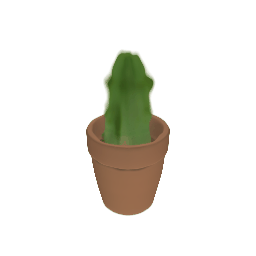

VRAM final                 0.01 GB allocated /  0.02 GB reserved


In [ ]:
DEFAULT_PROMPT = "a potted cactus"
try:
    user_prompt = input("prompt (blank = default): ").strip() or DEFAULT_PROMPT
except Exception as e:  # no stdin (headless render, CI, papermill)
    print(f"no interactive stdin ({type(e).__name__}), using default")
    user_prompt = DEFAULT_PROMPT
print("prompt:", user_prompt)

pipe = ShapEPipeline.from_pretrained(
    "openai/shap-e", torch_dtype=dtype,
    cache_dir=HF_CACHE,
).to(device)

t0 = time.perf_counter()
out = pipe(user_prompt, guidance_scale=15.0, num_inference_steps=64, frame_size=256).images[0]
print(f"{time.perf_counter() - t0:.1f}s")
display(IPyImage(filename=export_to_gif(out, str(OUT_DIR / "custom.gif"))))

# End of notebook - release everything.
del pipe, out, renders
free_memory()
vram("final")

## 13. Going Further

- **Run the real thing.** On a 24 GB+ card: `text -> image` with SDXL/FLUX (`04_Text_to_Image`), then [TRELLIS.2](https://github.com/microsoft/TRELLIS.2) (MIT, `trellis2` package) or [Hunyuan3D 2.1/3.0](https://github.com/Tencent-Hunyuan/Hunyuan3D-2.1) (open weights *and* training code, real PBR maps) for the 3D stage. Both are **vendor repos, not `diffusers` pipelines**, which is exactly why they are not runnable above. Watch the diffusers changelog - a native 3D pipeline family is the obvious next addition.
- **Sub-second image-to-3D.** [TripoSR](https://huggingface.co/stabilityai/TripoSR) (MIT, ~6 GB VRAM) and [Stable Fast 3D](https://huggingface.co/stabilityai/stable-fast-3d) (UV unwrapping + material estimation built in) via their vendor repos. See `15_Image_to_3D`.
- **Fix the mesh, which is most of the work.** Nothing above emits a shippable asset. The post-process is: decimate / retopologise (Blender's `Decimate`, Instant Meshes, quadriflow), UV unwrap (xatlas), bake albedo/normal/roughness maps, check manifoldness (`trimesh.is_watertight`, `is_winding_consistent`), and fix scale. This is what you pay Meshy/Tripo/Rodin for.
- **SDS, if you have time to burn.** [threestudio](https://github.com/threestudio-project/threestudio) is the reference implementation of DreamFusion, Magic3D, ProlificDreamer, Fantasia3D and MVDream under one config system. Still the way to get maximum fidelity on a single asset when 40 minutes of GPU is acceptable.
- **Fine-tuning.** Nobody fine-tunes text-to-3D end to end on a small budget. The practical lever is to fine-tune (or LoRA) the **2-D stage** on your art style, then feed the resulting images to a frozen image-to-3D model - the style transfers, the geometry model stays generic.
- **Scenes, not objects.** Everything here generates a single centred object. Text-to-*scene* (layout, multiple objects, a floor) is a separate and much less solved problem; 3D Gaussian Splatting scene generation is the active line.

**References**

- [DreamFusion: Text-to-3D using 2D Diffusion (Poole et al., 2022)](https://arxiv.org/abs/2209.14988) - the SDS paper
- [Magic3D (2022)](https://arxiv.org/abs/2211.10440), [ProlificDreamer / VSD (2023)](https://arxiv.org/abs/2305.16213), [Fantasia3D (2023)](https://arxiv.org/abs/2303.13873), [MVDream (2023)](https://arxiv.org/abs/2308.16512)
- [Point-E (2022)](https://arxiv.org/abs/2212.08751) and [Shap-E (2023)](https://arxiv.org/abs/2305.02463)
- [Zero-1-to-3 (2023)](https://arxiv.org/abs/2303.11328), [LRM: Large Reconstruction Model (2023)](https://arxiv.org/abs/2311.04400), [InstantMesh (2024)](https://arxiv.org/abs/2404.07191)
- [TRELLIS: Structured 3D Latents (2024)](https://arxiv.org/abs/2412.01506) and [TRELLIS.2 (2025)](https://github.com/microsoft/TRELLIS.2)
- [Hunyuan3D 2.0 (2025)](https://huggingface.co/papers/2501.12202) and the [Hunyuan3D-2.1 repo](https://github.com/Tencent-Hunyuan/Hunyuan3D-2.1)
- [3D Gaussian Splatting (Kerbl et al., SIGGRAPH 2023)](https://arxiv.org/abs/2308.04079)
- [Objaverse (2022)](https://arxiv.org/abs/2212.08051), [Objaverse-XL (2023)](https://arxiv.org/abs/2307.05663), [Cap3D (2023)](https://arxiv.org/abs/2306.07279)
- [T3Bench (2023)](https://arxiv.org/abs/2310.02977), [GPTEval3D (2024)](https://arxiv.org/abs/2401.04092), [3D Arena (2025)](https://arxiv.org/abs/2506.18787)
- [diffusers Shap-E guide](https://huggingface.co/docs/diffusers/main/en/using-diffusers/shap-e) and [3DGen-Arena leaderboard](https://huggingface.co/spaces/3DTopia/3DGen-Leaderboard)
- Related notebooks: `04_Text_to_Image`, `15_Image_to_3D`, `07_Image_to_Video`, `00_Depth_Estimation`

---